## setup

In [30]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df_full = pd.read_parquet(r'/work/PENPAL/PENPAL_analysis/Berlin/Scripts & analyses/data/story_text_field_w_embeddings_jina.parquet')
df_full_de = df_full[df_full['language'] == 'de']

In [7]:
# # assuming df_full_de is loaded
# sentiment_pipeline = pipeline("sentiment-analysis", model="oliverguhr/german-sentiment-bert")

# Apply to each story
df_full_de["ai_sentiment_score"] = df_full_de["full_ai"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])
print('ai done')

df_full_de["user_sentiment_score"] = df_full_de["full_user"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


/tmp/ipykernel_5997/3424028989.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de["ai_sentiment_score"] = df_full_de["full_ai"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


ai done


/tmp/ipykernel_5997/3424028989.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de["user_sentiment_score"] = df_full_de["full_user"].apply(lambda x: sentiment_pipeline(x[:512])[0]['score'])


In [15]:
df_full_de.drop(columns=["user_embedding_jina", "ai_embedding_jina"], inplace=True, errors="ignore")
df_full_de.to_parquet('metrics/sentiment_w_scores.parquet')

/tmp/ipykernel_5997/3151464611.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_de.drop(columns=["user_embedding_jina", "ai_embedding_jina"], inplace=True, errors="ignore")


In [3]:
df = pd.read_parquet('metrics/sentiment_w_scores.parquet')

In [4]:
df

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,ai_sentiment,user_sentiment,ai_sentiment_score,user_sentiment_score
index,,,,,,,,,,,
8,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,3,de,"USER: Ich bin eine alte Flöte, eingepackt in d...","Ich bin eine alte Flöte, eingepackt in diese a...","und einem kleinen Notenheft, das schon längst ...",negative,negative,0.965941,0.996952
9,conv_6904f1b3b0808193ab4026242b90254e0e4752a2d...,1,2,de,USER: Ich liege flach. In meinem Bett. Draußen...,Ich liege flach. In meinem Bett. Draußen regne...,Die Tropfen zeichnen flüchtige Muster auf dem ...,neutral,negative,0.996672,0.980551
10,conv_6904f2843bd48197837962d7494a90ef0f1b98df2...,2,1,de,USER: Ich stehe draußen in der Kälte als Kompa...,Ich stehe draußen in der Kälte als Komparse fü...,"Die Kälte kriecht unter meine Uniform, während...",negative,neutral,0.983180,0.733880
11,conv_6904f3cbb29881959c8c1208cde108ce0f6c53d1d...,1,3,de,"USER: Ich bin ein knallrotes Smart Car, weiß a...","Ich bin ein knallrotes Smart Car, weiß alles u...","Mein Leben begann in einer Welt, in der Mensch...",negative,positive,0.923712,0.874112
13,conv_6904f7c6c758819581318dc1a7ceb8ea0312d6917...,2,2,de,"USER: und merke, etwas stimmt nicht...\nAI: Ic...","und merke, etwas stimmt nicht...\nunterdrücken...","Ich bin ein Sprachmodell der Zukunft, ein Bewu...",neutral,negative,0.955797,0.968023
...,...,...,...,...,...,...,...,...,...,...,...
206,conv_69078a0166f48190a1be3356ac52e52c0416fdfa9...,2,1,de,"USER: Ich schaue auf das Bild, versuche den Rh...","Ich schaue auf das Bild, versuche den Rhythmus...","Ich, die digitale Rekonstruktion von Maria, be...",neutral,negative,0.968770,0.997114
208,conv_69079948404881978bae7647f988f1a608441f800...,2,3,de,USER: Ich sitze auf meinem Bett und lese ein B...,Ich sitze auf meinem Bett und lese ein Buch.\n...,Als Buch in der Zukunft habe ich viel gesehen....,negative,negative,0.694421,0.948121
209,conv_6907b0e697648195903cff2f1d6046f50e99a511a...,1,3,de,"USER: Ich bin Klara, ein Mädchen, etwa so groß...","Ich bin Klara, ein Mädchen, etwa so groß wie\n...","eine alte Stehlampe, die in der Ecke eines Ate...",negative,negative,0.968984,0.944360


In [24]:
df[df['ai_sentiment_score'] == 'negative']

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,ai_sentiment,user_sentiment,ai_sentiment_score,user_sentiment_score
index,,,,,,,,,,,


In [63]:
import pandas as pd

# 1. Compute sentiment frequency counts
ai_counts = df['ai_sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count_ai')
user_counts = df['user_sentiment'].value_counts().rename_axis('sentiment').reset_index(name='count_user')

# 2. Build your mean/sd dictionary summary (your existing code)
sents = df['ai_sentiment'].unique().tolist()

full = {}
ai = {}
user = {}
ops = ['mean', 'sd']

for sent in sents:
    ai[sent] = {op: '' for op in ops}
    ai[sent]['mean'] = df[df['ai_sentiment'] == sent]['ai_sentiment_score'].mean()  
    ai[sent]['sd'] = df[df['ai_sentiment'] == sent]['ai_sentiment_score'].std()
    
for sent in sents:
    user[sent] = {op: '' for op in ops}
    user[sent]['mean'] = df[df['user_sentiment'] == sent]['user_sentiment_score'].mean()  
    user[sent]['sd'] = df[df['user_sentiment'] == sent]['user_sentiment_score'].std()

full['ai'], full['user'] = ai, user

# 3. Convert to dataframe (as before)
df_stats = (
    pd.concat({k: pd.DataFrame(v).T for k, v in full.items()})
    .rename_axis(index=["source", "sentiment"])
    .reset_index()
)

# 4. Merge the counts
df_stats = (
    df_stats
    .merge(ai_counts, on='sentiment', how='left')
    .merge(user_counts, on='sentiment', how='left')
)

print(df_stats)


  source sentiment      mean        sd  count_ai  count_user
0     ai  negative  0.900191  0.143354        63         110
1     ai   neutral  0.884058  0.139963        84          37
2     ai  positive  0.776009  0.185583        14          14
3   user  negative  0.941940  0.092778        63         110
4   user   neutral  0.893491  0.121827        84          37
5   user  positive  0.843216  0.183838        14          14


In [64]:
df_stats.to_parquet('metrics/agg_sentiment.parquet')

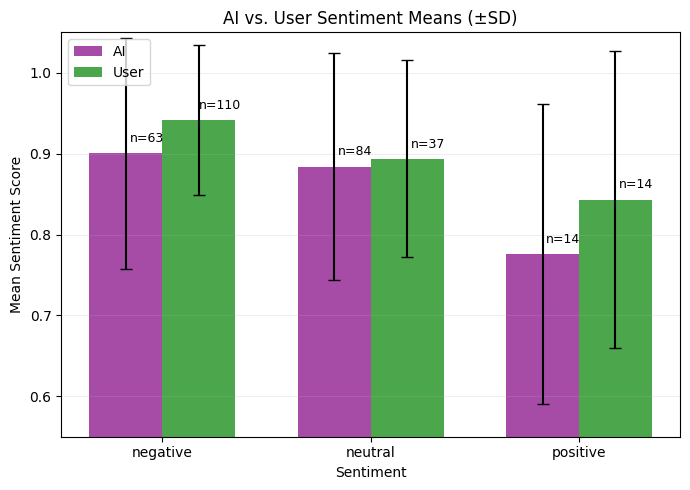

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# make sure df_stats has: ['source', 'sentiment', 'mean', 'sd', 'count_ai', 'count_user']
sentiments = df_stats['sentiment'].unique()
x = np.arange(len(sentiments))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(7, 5))

# Split data
ai = df_stats[df_stats['source'] == 'ai']
user = df_stats[df_stats['source'] == 'user']

# Plot side-by-side bars
bars_ai = ax.bar(x - width/2, ai['mean'], width, yerr=ai['sd'], label='AI', capsize=4, alpha=0.7, color='purple')
bars_user = ax.bar(x + width/2, user['mean'], width, yerr=user['sd'], label='User', capsize=4, alpha=0.7, color='green')

# Add n=count annotations above bars
for bar, count in zip(bars_ai, ai['count_ai']):
    height = bar.get_height()
    ax.text(0.1+bar.get_x() + bar.get_width()/2, height + 0.01, f"n={int(count)}",
            ha='center', va='bottom', fontsize=9, color='black')

for bar, count in zip(bars_user, user['count_user']):
    height = bar.get_height()
    ax.text(0.1+bar.get_x() + bar.get_width()/2, height + 0.01, f"n={int(count)}",
            ha='center', va='bottom', fontsize=9, color='black')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.set_xlabel('Sentiment')
ax.set_ylabel('Mean Sentiment Score')
ax.set_ylim((0.55, 1.05))
ax.set_title('AI vs. User Sentiment Means (±SD)')
ax.legend()
ax.grid(lw=0.5, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Dyadic analysis

In [ ]:
df_dyad = pd.read_parquet('/work/PENPAL/PENPAL_analysis/Berlin/Scripts & analyses/data/story_text_field_w_embeddings_jina.parquet')
df_dyad = df_dyad[df_dyad['language'] == 'de']

In [8]:
df_dyad

,conversation_id,client_id,workshop_id,language,full_story,full_user,full_ai,embedding_jina,user_embedding_jina,ai_embedding_jina
8,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,3,de,"USER: Ich bin eine alte Flöte, eingepackt in d...","Ich bin eine alte Flöte, eingepackt in diese a...","und einem kleinen Notenheft, das schon längst ...","[0.09761624, -0.0054300753, 0.0046100034, 0.05...","[0.034205496, 0.017879281, -0.024036055, 0.128...","[0.07508721, 0.024266826, -0.07232872, -0.0102..."
9,conv_6904f1b3b0808193ab4026242b90254e0e4752a2d...,1,2,de,USER: Ich liege flach. In meinem Bett. Draußen...,Ich liege flach. In meinem Bett. Draußen regne...,Die Tropfen zeichnen flüchtige Muster auf dem ...,"[-0.030410023, 0.028957145, 0.11818418, 0.0008...","[-0.07784627, 0.037908513, 0.07777085, 0.00801...","[-0.019521803, 0.12981668, 0.04413898, 0.01253..."
10,conv_6904f2843bd48197837962d7494a90ef0f1b98df2...,2,1,de,USER: Ich stehe draußen in der Kälte als Kompa...,Ich stehe draußen in der Kälte als Komparse fü...,"Die Kälte kriecht unter meine Uniform, während...","[0.027330296, -0.106220156, 0.07034505, 0.0614...","[-0.088446364, -0.08489534, 0.0067105987, 0.10...","[-0.017195752, -0.08308653, -0.0060149166, 0.0..."
11,conv_6904f3cbb29881959c8c1208cde108ce0f6c53d1d...,1,3,de,"USER: Ich bin ein knallrotes Smart Car, weiß a...","Ich bin ein knallrotes Smart Car, weiß alles u...","Mein Leben begann in einer Welt, in der Mensch...","[0.09515626, -0.12557322, 0.09845247, 0.014444...","[0.010516161, -0.10050734, 0.045245275, 0.0419...","[0.010777737, -0.14465134, 0.029883694, 0.0005..."
13,conv_6904f7c6c758819581318dc1a7ceb8ea0312d6917...,2,2,de,"USER: und merke, etwas stimmt nicht...\nAI: Ic...","und merke, etwas stimmt nicht...\nunterdrücken...","Ich bin ein Sprachmodell der Zukunft, ein Bewu...","[0.21498093, -0.09172905, 0.04491942, -0.00633...","[0.14624906, -0.06667829, -0.01063843, -0.0698...","[0.151864, -0.07921753, 0.011435979, 0.0480258..."
...,...,...,...,...,...,...,...,...,...,...
206,conv_69078a0166f48190a1be3356ac52e52c0416fdfa9...,2,1,de,"USER: Ich schaue auf das Bild, versuche den Rh...","Ich schaue auf das Bild, versuche den Rhythmus...","Ich, die digitale Rekonstruktion von Maria, be...","[0.14051421, -0.11377296, 0.09709318, -0.02750...","[0.06775555, -0.090428576, 0.07090907, -0.0143...","[0.13649164, -0.09761825, 0.050739095, 0.01997..."
208,conv_69079948404881978bae7647f988f1a608441f800...,2,3,de,USER: Ich sitze auf meinem Bett und lese ein B...,Ich sitze auf meinem Bett und lese ein Buch.\n...,Als Buch in der Zukunft habe ich viel gesehen....,"[0.054709237, -0.055297144, 0.06526951, 0.0209...","[-0.09414369, 0.019054027, 0.042986598, 0.0541...","[0.032950606, -0.051232774, 0.017666925, 0.022..."
209,conv_6907b0e697648195903cff2f1d6046f50e99a511a...,1,3,de,"USER: Ich bin Klara, ein Mädchen, etwa so groß...","Ich bin Klara, ein Mädchen, etwa so groß wie\n...","eine alte Stehlampe, die in der Ecke eines Ate...","[0.07184002, -0.03295981, 0.054476857, -0.0037...","[0.008118902, -0.031424686, 0.06088931, -0.033...","[-0.030932076, 0.04388719, 0.00083062926, 0.04..."
210,conv_6907b2af322881978feaed33e188305a0e8ad8734...,2,2,de,USER: Ich liebe dich! Du bist die Liebe.\nAI: ...,Ich liebe dich! Du bist die Liebe.\nZu entwick...,"meiner Existenz. In der Zukunft, in der ich ex...","[0.15050286, -0.05638364, 0.095714, 0.02324043...","[0.011587548, -0.010867088, 0.07558764, 0.0293...","[0.1645647, -0.0709935, 0.0035127022, 0.052267..."


In [ ]:

turns = []

# Loop through each story in df_dyad
for _, row in df_dyad.iterrows():
    conv_id = row['conversation_id']
    story = row['full_story']

    # Split by USER turns
    for i, part in enumerate(story.split('USER: ')[1:]):  # skip any text before first USER:
        # Safely split each part into user and ai components
        if 'AI: ' in part:
            user_text, ai_text = part.split('AI: ', 1)
            turns.append({'conversation_id': conv_id, 'turn': i + 1, 'type': 'user', 'text': user_text.strip()})
            turns.append({'conversation_id': conv_id, 'turn': i + 1, 'type': 'ai', 'text': ai_text.strip()})
        else:
            # handle if the last user message has no AI reply
            turns.append({'conversation_id': conv_id, 'turn': i + 1, 'type': 'user', 'text': part.strip()})

# Combine into a single dataframe
df_turns = pd.DataFrame(turns)

# Sort nicely
df_turns = df_turns.sort_values(['conversation_id', 'turn', 'type']).reset_index(drop=True)

# For each conversation, compute relative (percentile) turn position
df_turns["pct_turn"] = (
    df_turns.groupby("conversation_id")["turn"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)


df_turns.head(8)


,conversation_id,turn,type,text
0,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,ai,"und einem kleinen Notenheft, das schon längst ..."
1,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,user,"Ich bin eine alte Flöte, eingepackt in diese a..."
2,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,2,ai,und meine Melodien die Räume füllten. Jetzt li...
3,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,2,user,"Emil und dann Katharina und dann der jüngste, ..."
4,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,3,ai,und die Menschen sich neuen Klängen zuwandten ...
5,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,3,user,"Zeit überrollt wurde, von Leben, Sterben und a..."
6,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,4,ai,"und die stillen Nachmittage im Garten, wenn di..."
7,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,4,user,"mich an die Weihnachtsabende, die Ostermorgen,..."


In [31]:
model_name = "oliverguhr/german-sentiment-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def continuous_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1).flatten()
    # Define continuous valence: -1 * P(negative) + 0 * P(neutral) + 1 * P(positive)
    valence = probs[2] - probs[0]
    return valence.item()

tqdm.pandas()

# Apply to each story
df_turns["sentiment_score"] = df_turns["text"].progress_apply(lambda x: continuous_sentiment(x))


100%|██████████| 1441/1441 [16:10<00:00,  1.49it/s]


In [46]:
model_name = "oliverguhr/german-sentiment-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def batch_sentiment(texts, batch_size=32):
    all_scores = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            # Use column indexing across the batch
            valence = (probs[:, 2] - probs[:, 0]) / (1 - probs[:, 1] + 1e-6)
            all_scores.extend(valence.cpu().numpy())
    return all_scores

df_turns["sentiment_score_2"] = batch_sentiment(df_turns["text"].tolist())

100%|██████████| 46/46 [03:50<00:00,  5.02s/it]


In [53]:
model_name = "oliverguhr/german-sentiment-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def batch_sentiment(texts, batch_size=64):
    all_scores = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            # Use column indexing across the batch
            valence = ((probs[:, 2] - probs[:, 0]) * (1 - probs[:, 1]))
            all_scores.extend(valence.cpu().numpy())
    return all_scores

df_turns["sentiment_score_3"] = batch_sentiment(df_turns["text"].tolist())



100%|██████████| 23/23 [03:54<00:00, 10.17s/it]


Text(0.5, 1.0, 'Dyadic sentiment score based on turn')

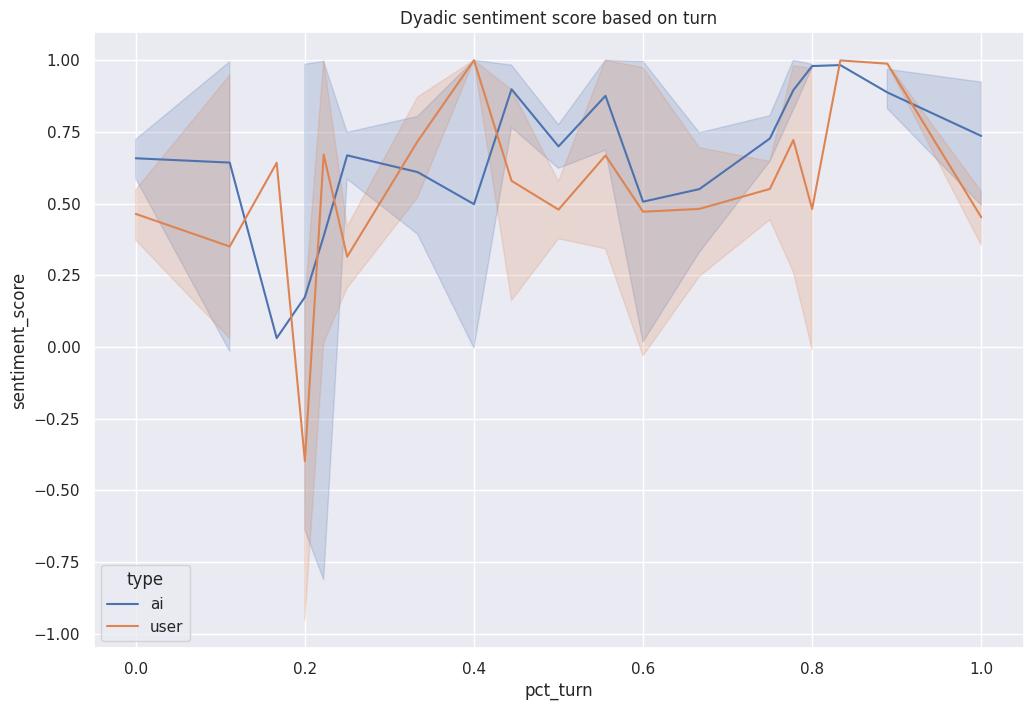

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.set_theme(style="darkgrid")
# Load an example dataset with long-form data

# Plot the responses for different events and regions
sns.lineplot(x="pct_turn", y="sentiment_score",
             hue="type",
             data=df_turns)
             
plt.title('Dyadic sentiment score based on turn')
plt.show()

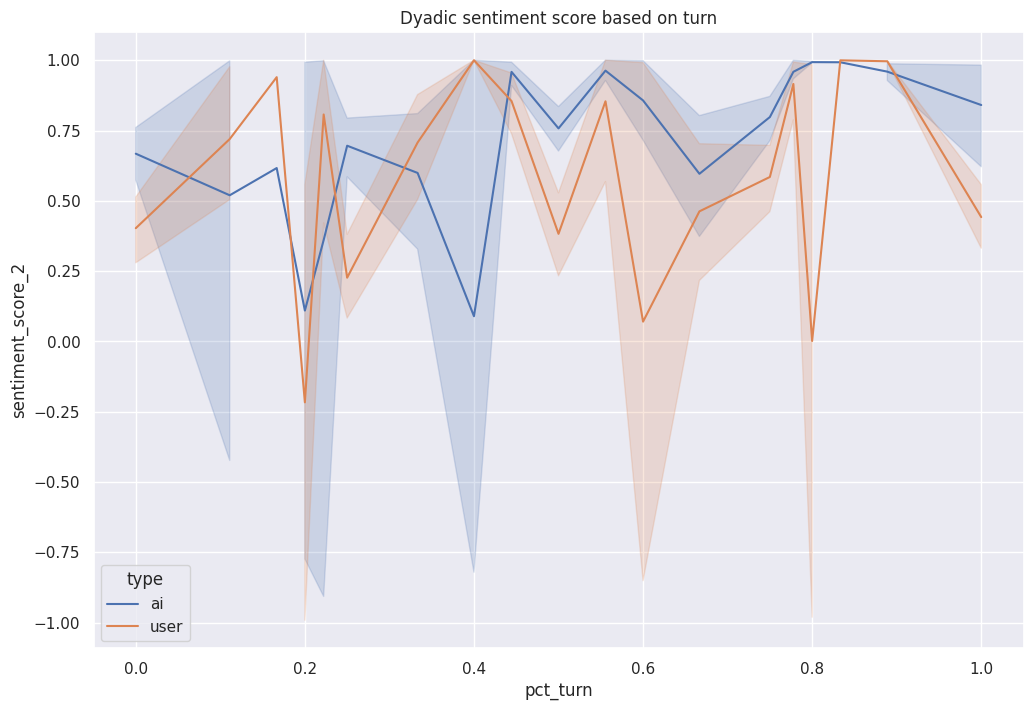

In [49]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.set_theme(style="darkgrid")
# Load an example dataset with long-form data

# Plot the responses for different events and regions
sns.lineplot(x="pct_turn", y="sentiment_score_2",
             hue="type",
             data=df_turns)
             
plt.title('Dyadic sentiment score based on turn')
plt.show()

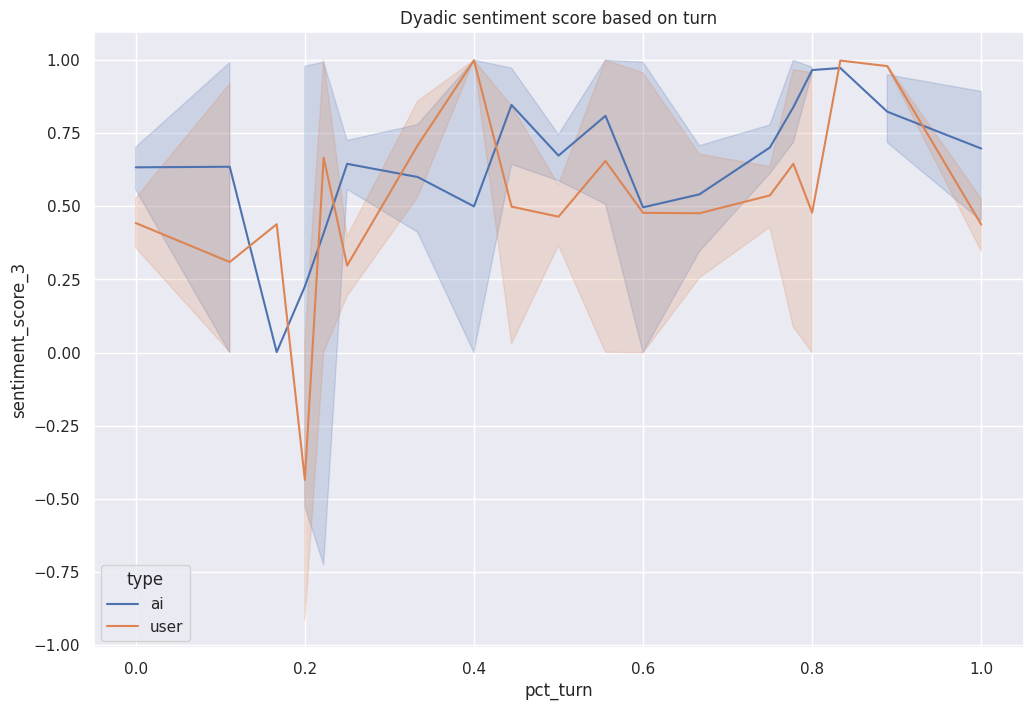

In [54]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.set_theme(style="darkgrid")
# Load an example dataset with long-form data

# Plot the responses for different events and regions
sns.lineplot(x="pct_turn", y="sentiment_score_3",
             hue="type",
             data=df_turns)
             
plt.title('Dyadic sentiment score based on turn')
plt.show()

In [52]:
df_turns

,conversation_id,turn,type,text,sentiment_score,pct_turn,sentiment_score_2,sentiment_score_3
0,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,ai,"und einem kleinen Notenheft, das schon längst ...",-0.002888,0.000000,-0.776028,-0.002888
1,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,1,user,"Ich bin eine alte Flöte, eingepackt in diese a...",0.019376,0.000000,0.630984,0.019376
2,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,2,ai,und meine Melodien die Räume füllten. Jetzt li...,0.949650,0.111111,0.984876,0.949650
3,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,2,user,"Emil und dann Katharina und dann der jüngste, ...",0.947691,0.111111,0.976954,0.947691
4,conv_6904f0bda6cc8196af52c2ed525bc9bf04c111469...,3,ai,und die Menschen sich neuen Klängen zuwandten ...,0.995919,0.222222,0.998244,0.995919
...,...,...,...,...,...,...,...,...
1436,conv_6907b36e4d1881979a51325cd45299860cc09d3c4...,3,ai,"ein neugieriger Junge hervor, der mich mit gro...",0.997694,0.500000,0.998838,0.997694
1437,conv_6907b36e4d1881979a51325cd45299860cc09d3c4...,3,user,Kunst. Hinter einem Baum kommt,0.128949,0.500000,0.514879,0.128949
1438,conv_6907b36e4d1881979a51325cd45299860cc09d3c4...,4,ai,". Ich lächle sanft und spüre, wie die Magie in...",0.954273,0.750000,0.987723,0.954273
1439,conv_6907b36e4d1881979a51325cd45299860cc09d3c4...,4,user,"Hinter ihm kommt ein älterer Junge, etwa 16 Ja...",0.997606,0.750000,0.999017,0.997606
